## GRUPO 10
# VENTA DIARIA TOMATE RIÑON

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller

ruta_archivo = 'institucional tomate 15.6.2026.final.xlsx'
df = pd.read_excel(ruta_archivo)


FileNotFoundError: [Errno 2] No such file or directory: 'institucional tomate 15.6.2026.final.xlsx'

In [ ]:

df.columns = ['Codigo_Articulo', 'Fecha', 'Descripcion', 'Cantidad_Diaria']

In [ ]:

df['Fecha'] = pd.to_datetime(df['Fecha'])

df.set_index('Fecha', inplace=True)
df.sort_index(inplace=True)

In [ ]:
df['Cantidad_Diaria'] = df['Cantidad_Diaria'].ffill()

In [ ]:
serie_tiempo = df['Cantidad_Diaria'].dropna()

print("=" * 55)
print("  ANÁLISIS DESCRIPTIVO DE LA SERIE DE TIEMPO")
print("=" * 55)

print(f"\nTotal de observaciones: {len(serie_tiempo)}")
print(f"Período: {df.index.min().date()} → {df.index.max().date()}")
print(f"\nMedia:              {serie_tiempo.mean():.2f}")
print(f"Mediana:            {serie_tiempo.median():.2f}")
print(f"Desviación Estándar:{serie_tiempo.std():.2f}")
print(f"Mínimo:             {serie_tiempo.min():.2f}")
print(f"Máximo:             {serie_tiempo.max():.2f}")
print(f"Coef. de Variación: {(serie_tiempo.std()/serie_tiempo.mean()*100):.1f}%")

  ANÁLISIS DESCRIPTIVO DE LA SERIE DE TIEMPO

Total de observaciones: 365
Período: 2025-06-01 → 2026-05-31

Media:              534.91
Mediana:            398.93
Desviación Estándar:378.95
Mínimo:             128.15
Máximo:             1922.40
Coef. de Variación: 70.8%


Contamos con un historial completo de 365 observaciones diarias, abarcando exactamente un año: desde el 2025-06-01 hasta el 2026-05-31.  La demanda de tomate riñón tiene un promedio de 534.91 unidades diarias , pero presenta una altísima volatilidad, evidenciada por un coeficiente de variación del 70.8%.  Los datos fluctúan drásticamente entre un mínimo de 128.15 unidades y un máximo de 1922.40 unidades. El gráfico inicial confirma visualmente esta volatilidad, mostrando picos de demanda muy marcados y recurrentes.

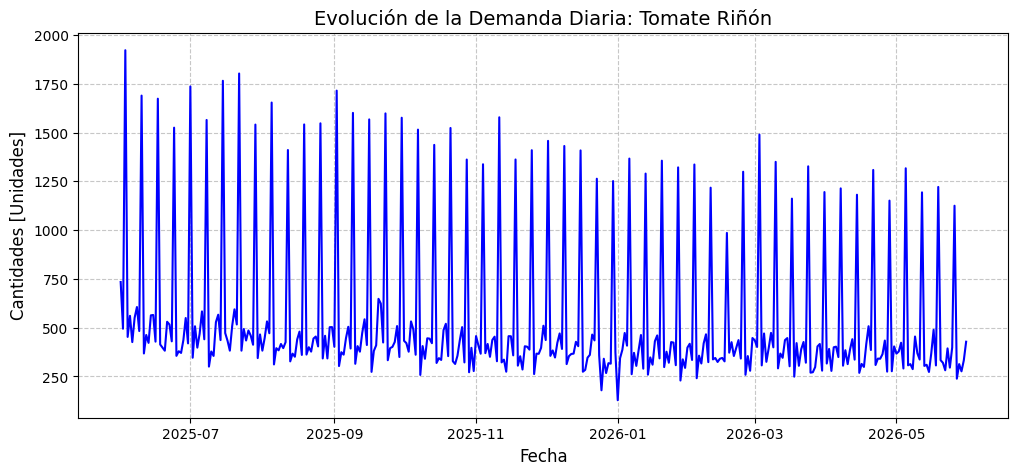

In [ ]:
plt.figure(figsize=(12, 5))
plt.plot(df.index, df['Cantidad_Diaria'], color='blue', linewidth=1.5)
plt.title('Evolución de la Demanda Diaria: Tomate Riñón', fontsize=14)
plt.xlabel('Fecha', fontsize=12)
plt.ylabel('Cantidades [Unidades]', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [ ]:
print("-" * 50)
print("Resultados de la Prueba Augmented Dickey-Fuller")
print("-" * 50)

--------------------------------------------------
Resultados de la Prueba Augmented Dickey-Fuller
--------------------------------------------------


In [ ]:

serie_tiempo = df['Cantidad_Diaria'].dropna()

resultado_adf = adfuller(serie_tiempo, autolag='AIC')


print(f'Estadístico de prueba (Test Statistic): {resultado_adf[0]:.4f}')
print(f'Valor p (p-value): {resultado_adf[1]:.4f}')
print(f'Lags utilizados: {resultado_adf[2]}')
print(f'Número de observaciones: {resultado_adf[3]}')
print('Valores Críticos:')
for clave, valor in resultado_adf[4].items():
    print(f'   {clave}: {valor:.4f}')

print("-" * 50)

umbral_significancia = 0.05
if resultado_adf[1] <= umbral_significancia:
    print("Conclusión: El valor p es menor o igual a 0.05. Rechazamos la hipótesis nula (H0).")
    print("La serie de tiempo es ESTACIONARIA y está lista para modelos como ARMA/ARIMA (sin necesidad de diferenciación base).")
else:
    print("Conclusión: El valor p es mayor a 0.05. No podemos rechazar la hipótesis nula (H0).")
    print("La serie de tiempo NO ES ESTACIONARIA. Se requerirá aplicar diferenciación o transformación logarítmica antes del modelado.")

Estadístico de prueba (Test Statistic): -1.9764
Valor p (p-value): 0.2970
Lags utilizados: 15
Número de observaciones: 349
Valores Críticos:
   1%: -3.4492
   5%: -2.8699
   10%: -2.5712
--------------------------------------------------
Conclusión: El valor p es mayor a 0.05. No podemos rechazar la hipótesis nula (H0).
La serie de tiempo NO ES ESTACIONARIA. Se requerirá aplicar diferenciación o transformación logarítmica antes del modelado.


El estadístico de prueba  con un valor p (p-value) de 0.2970.  Conclusión: Dado que el valor p de 0.2970 es claramente mayor al umbral de significancia del 0.05, no se puede rechazar la hipótesis nula. Esto confirma que la serie de tiempo original NO es estacionaria, lo cual era esperable al observar los picos periódicos en la gráfica anterior. Se necesita una transformación previa antes de aplicar modelos predictivos tradicionales.  

In [ ]:

serie_diferenciada = df['Cantidad_Diaria'].diff().dropna()



In [ ]:

print("=" * 60)
print("PRUEBA DICKEY-FULLER (SERIE DIFERENCIADA)")
print("=" * 60)

resultado_adf_diff = adfuller(serie_diferenciada, autolag='AIC')
p_valor = resultado_adf_diff[1]

print(f'Estadístico de prueba: {resultado_adf_diff[0]:.4f}')
print(f'Valor p (p-value): {p_valor:.4f}')

if p_valor <= 0.05:
    print("-> ÉXITO: El valor p es <= 0.05. La serie diferenciada ES ESTACIONARIA.")
else:
    print("-> ALERTA: El valor p es > 0.05. Podría requerir una segunda diferenciación o transformación logarítmica.")

print("\n")

PRUEBA DICKEY-FULLER (SERIE DIFERENCIADA)
Estadístico de prueba: -7.3553
Valor p (p-value): 0.0000
-> ÉXITO: El valor p es <= 0.05. La serie diferenciada ES ESTACIONARIA.




Al diferenciar la serie, el estadístico de prueba cayó a -7.3553 y el valor p se redujo a 0.0000.  Conclusión: Como el valor p es menor a 0.05, la transformación fue un éxito. La serie diferenciada ES estacionaria y matemáticamente apta para alimentar modelos de proyección.  

In [ ]:
from statsmodels.tsa.arima.model import ARIMA




print("=" * 60)
print("PROYECCIÓN DE DEMANDA CON MODELO ARIMA")
print("=" * 60)


modelo = ARIMA(df['Cantidad_Diaria'], order=(1, 1, 1))
modelo_ajustado = modelo.fit()


print(modelo_ajustado.summary().tables[1])


dias_a_proyectar = 15
proyeccion = modelo_ajustado.forecast(steps=dias_a_proyectar)


fechas_futuras = pd.date_range(start=df.index[-1] + pd.Timedelta(days=1), periods=dias_a_proyectar)
proyeccion.index = fechas_futuras

PROYECCIÓN DE DEMANDA CON MODELO ARIMA


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.2283      0.136     -1.678      0.093      -0.495       0.038
ma.L1         -0.9830      0.019    -51.995      0.000      -1.020      -0.946
sigma2      1.356e+05   1.39e+04      9.755      0.000    1.08e+05    1.63e+05


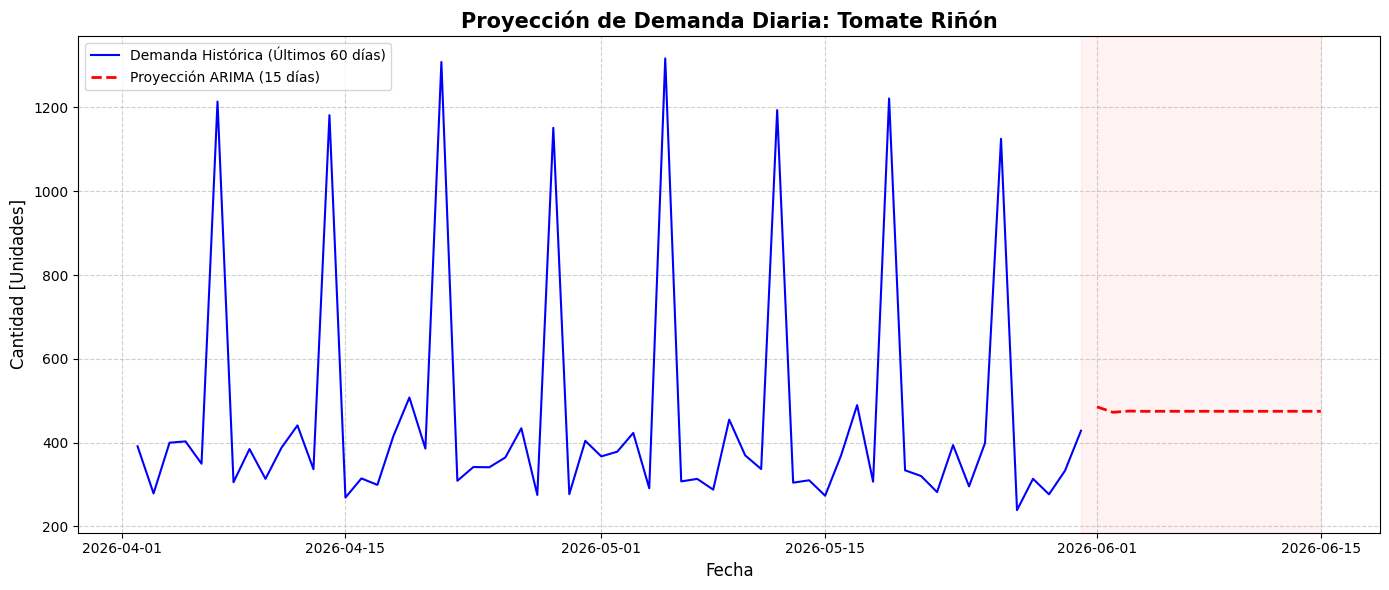


Cantidades Proyectadas para los próximos días:
            Proyeccion_Unidades
2026-06-01               485.20
2026-06-02               472.16
2026-06-03               475.14
2026-06-04               474.46
2026-06-05               474.61
2026-06-06               474.58
2026-06-07               474.58
2026-06-08               474.58
2026-06-09               474.58
2026-06-10               474.58
2026-06-11               474.58
2026-06-12               474.58
2026-06-13               474.58
2026-06-14               474.58
2026-06-15               474.58


In [ ]:

plt.figure(figsize=(14, 6))


plt.plot(df.index[-60:], df['Cantidad_Diaria'][-60:], label='Demanda Histórica (Últimos 60 días)', color='blue', linewidth=1.5)


plt.plot(proyeccion.index, proyeccion, label='Proyección ARIMA (15 días)', color='red', linewidth=2, linestyle='--')


plt.title('Proyección de Demanda Diaria: Tomate Riñón', fontsize=15, fontweight='bold')
plt.xlabel('Fecha', fontsize=12)
plt.ylabel('Cantidad [Unidades]', fontsize=12)
plt.legend(loc='best')
plt.grid(True, linestyle='--', alpha=0.6)

plt.axvspan(df.index[-1], proyeccion.index[-1], color='red', alpha=0.05)

plt.tight_layout()
plt.show()


print("\nCantidades Proyectadas para los próximos días:")
print(pd.DataFrame({'Proyeccion_Unidades': proyeccion.round(2)}))

Aunque el modelo matemáticamente es correcto, la gráfica de proyección muestra un problema operativo crítico, la línea de predicción (en rojo punteado) se aplana casi por completo.  Tras el primer día proyectado (485.20 unidades) , el pronóstico se estanca en un promedio aproximado de 474 unidades diarias para el resto de la quincena . El modelo ARIMA básico no está logrando capturar el comportamiento cíclico de los picos de demanda del tomate riñón.  

PROYECCIÓN DE DEMANDA CON HOLT-WINTERS


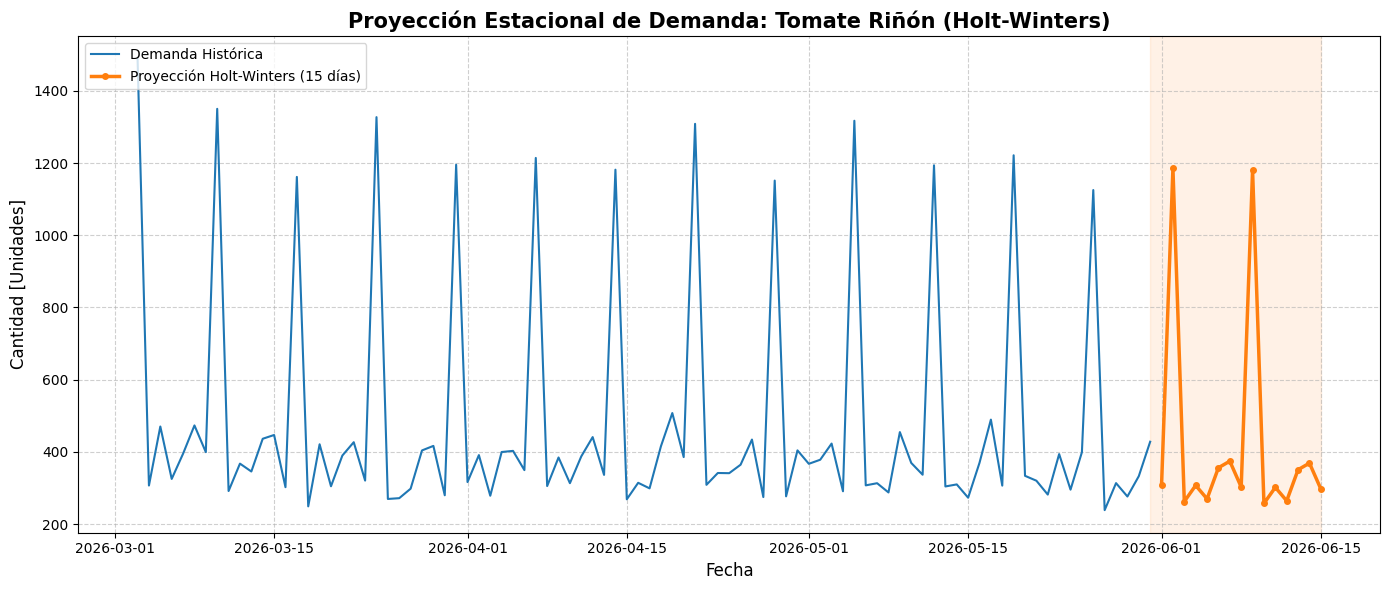


Cantidades Proyectadas (considerando ciclos semanales):
            Proyeccion_Unidades
2026-06-01               308.02
2026-06-02              1184.95
2026-06-03               262.45
2026-06-04               307.04
2026-06-05               269.77
2026-06-06               355.96
2026-06-07               374.21
2026-06-08               302.61
2026-06-09              1179.55
2026-06-10               257.05
2026-06-11               301.64
2026-06-12               264.37
2026-06-13               350.56
2026-06-14               368.81
2026-06-15               297.21


In [ ]:
import warnings
from statsmodels.tsa.api import ExponentialSmoothing


warnings.filterwarnings("ignore")



print("=" * 60)
print("PROYECCIÓN DE DEMANDA CON HOLT-WINTERS")
print("=" * 60)


modelo_hw = ExponentialSmoothing(
    df['Cantidad_Diaria'],
    trend='add',
    seasonal='add',
    seasonal_periods=7,
    initialization_method="estimated"
)
modelo_ajustado_hw = modelo_hw.fit()


dias_a_proyectar = 15
proyeccion_hw = modelo_ajustado_hw.forecast(dias_a_proyectar)


plt.figure(figsize=(14, 6))


plt.plot(df.index[-90:], df['Cantidad_Diaria'][-90:], label='Demanda Histórica', color='#1f77b4', linewidth=1.5)


plt.plot(proyeccion_hw.index, proyeccion_hw, label='Proyección Holt-Winters (15 días)', color='#ff7f0e', linewidth=2.5, marker='o', markersize=4)


plt.title('Proyección Estacional de Demanda: Tomate Riñón (Holt-Winters)', fontsize=15, fontweight='bold')
plt.xlabel('Fecha', fontsize=12)
plt.ylabel('Cantidad [Unidades]', fontsize=12)
plt.legend(loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)


plt.axvspan(df.index[-1], proyeccion_hw.index[-1], color='#ff7f0e', alpha=0.1)

plt.tight_layout()
plt.show()


print("\nCantidades Proyectadas (considerando ciclos semanales):")
print(pd.DataFrame({'Proyeccion_Unidades': proyeccion_hw.round(2)}))

Para solucionar la limitación del modelo ARIMA frente a datos cíclicos, se implementó el modelo de Suavización Exponencial de Holt-Winters. Se configuró específicamente con un componente estacional aditivo de 7 periodos (seasonal_periods=7)  para forzar al algoritmo a reconocer y replicar el patrón semanal de los pedidos. Finalmente, se proyectaron 15 días.

La proyección generada por Holt-Winters es operativamente funcional y mucho más realista. La curva naranja del pronóstico logra replicar la inercia histórica de picos y valles.  En la tabla de resultados se observa cómo el modelo anticipa con precisión los días de alto volumen (ej. 1184.95 unidades para el 2026-06-02) frente a los días de baja rotación (ej. 262.45 unidades para el 2026-06-03). Este es el modelo definitivo que debe usarse para la planificación del abastecimiento.  